<a href="https://colab.research.google.com/github/Fajtos/hzmps-surveillance/blob/main/Chikungunya_application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Second Empirical Application: Chikungunya in São Paulo Municipalities

**Purpose:** Extend the empirical evaluation to a disease with a **different zero
structure** than dengue. Chikungunya exhibits both zero-inflated quiescent years
and zero-deflated outbreak years, providing a direct test of whether the HZMPS
model's flexibility translates into improved predictive performance.

**Design:** The same 50 municipalities used in the dengue application, over the
same 104-week window. Identical model structure and priors across all four
competing models (HZMPS, ZIP, ZINB, HNB), so the comparison is fair.

**Expected outcome:** If HZMPS's theoretical advantage is real, its WAIC should
be closer to (or lower than) the baselines here than it was for dengue.

**Workflow:**
1. Download chikungunya data
2. Build panel (same 50 municipalities)
3. Fit all four models
4. Compare WAIC
5. Interpret in the context of the dengue result

In [ ]:
# CELL 2: SETUP
!pip install --upgrade cmdstanpy -q

import os, urllib.request, shutil
CMDSTAN_DIR = '/content/cmdstan-2.36.0'
if not os.path.exists(os.path.join(CMDSTAN_DIR, 'makefile')):
    os.chdir('/content')
    tgz_file = '/content/colab-cmdstan-2.36.0.tar.gz'
    tgz_url = ('https://github.com/stan-dev/cmdstan/releases/download/'
               'v2.36.0/colab-cmdstan-2.36.0.tgz')
    if not os.path.exists(tgz_file):
        urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file, '/content')
os.environ['CMDSTAN'] = CMDSTAN_DIR

import cmdstanpy, numpy as np, pandas as pd, requests, io, time
print(f"CmdStan: {cmdstanpy.cmdstan_version()}")

CmdStan: (2, 36)


In [ ]:
# CELL 3: DOWNLOAD CHIKUNGUNYA DATA FOR SAME 50 MUNICIPALITIES
import requests, pandas as pd, io, time

# Same municipality list as the dengue application
url = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/SP/municipios"
df_sp = pd.DataFrame([
    {'geocode': m['id'], 'name': m['nome']} for m in requests.get(url).json()
])

N_MUN = 50
np.random.seed(42)   # same seed → same municipalities
selected = df_sp.sample(N_MUN, random_state=42).reset_index(drop=True)

all_data = []
failed = []
for i, row in selected.iterrows():
    geocode = int(row['geocode'])
    url_api = (f"https://info.dengue.mat.br/api/alertcity"
               f"?geocode={geocode}"
               f"&disease=chikungunya"          # <-- changed from dengue
               f"&format=csv"
               f"&ew_start=1&ew_end=53"
               f"&ey_start=2019&ey_end=2023")
    try:
        r = requests.get(url_api, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
        df['unit_id'] = geocode
        all_data.append(df)
        print(f"[{i+1}/{len(selected)}] {row['name']}: {len(df)} weeks")
    except Exception as e:
        failed.append((geocode, row['name'], str(e)))
        print(f"[{i+1}/{len(selected)}] {row['name']}: FAILED ({e})")
    time.sleep(0.3)

df_raw = pd.concat(all_data, ignore_index=True)
print(f"\nDownloaded: {len(df_raw)} rows, {df_raw['unit_id'].nunique()} municipalities")
print(f"Failed: {len(failed)}")

[1/50] Vargem Grande do Sul: 261 weeks
[2/50] Taiúva: 261 weeks
[3/50] Taquarituba: 261 weeks
[4/50] Júlio Mesquita: 261 weeks
[5/50] Bilac: 261 weeks
[6/50] Chavantes: 261 weeks
[7/50] Taquaral: 261 weeks
[8/50] Palmeira d'Oeste: 261 weeks
[9/50] Santa Adélia: 261 weeks
[10/50] Estrela do Norte: 261 weeks
[11/50] Natividade da Serra: 261 weeks
[12/50] Fernandópolis: 261 weeks
[13/50] Flora Rica: 261 weeks
[14/50] Borá: 261 weeks
[15/50] Capela do Alto: 261 weeks
[16/50] Mairinque: 261 weeks
[17/50] Nantes: 261 weeks
[18/50] Dobrada: 261 weeks
[19/50] Bento de Abreu: 261 weeks
[20/50] Altair: 261 weeks
[21/50] Platina: 261 weeks
[22/50] Barrinha: 261 weeks
[23/50] Novais: 261 weeks
[24/50] Bálsamo: 261 weeks
[25/50] Santa Rita d'Oeste: 261 weeks
[26/50] Valentim Gentil: 261 weeks
[27/50] São José da Bela Vista: 261 weeks
[28/50] Parapuã: 261 weeks
[29/50] Piratininga: 261 weeks
[30/50] Araçatuba: 261 weeks
[31/50] Guarani d'Oeste: 261 weeks
[32/50] Bananal: 261 weeks
[33/50] Lindóia: 2

In [ ]:
# CELL 4: BUILD CHIKUNGUNYA PANEL (104 WEEKS)
df_raw['date'] = pd.to_datetime(df_raw['data_iniSE'])
df_raw['year'] = df_raw['date'].dt.year
df_raw['week'] = df_raw['date'].dt.isocalendar().week.astype(int)
df_raw['time_idx'] = df_raw['year'] * 100 + df_raw['week']

panel_full = df_raw.pivot_table(
    index='unit_id', columns='time_idx', values='casos', aggfunc='sum'
).fillna(0)

# Truncate to last 104 weeks
panel = panel_full.iloc[:, -104:]
Y = panel.values.astype(int)
N, T = panel.shape
M = N * T

print(f"Panel shape: N={N}, T={T}, M={M}")
print(f"Zero fraction: {(Y==0).mean():.3f}")
print(f"Mean count: {Y.mean():.3f}")
print(f"Max count: {Y.max()}")

# Compare to dengue summary
print(f"\nComparison with dengue:")
print(f"  Dengue zero fraction: 0.456")
print(f"  Chikungunya zero fraction: {(Y==0).mean():.3f}")

# Prepare for Stan
y_flat   = Y.flatten().tolist()
unit_idx = np.repeat(np.arange(1, N+1), T).tolist()
time_idx = np.tile(np.arange(1, T+1), N).tolist()

base_data = {
    'N': N, 'T': T, 'G': 10,
    'y': y_flat, 'unit': unit_idx, 'time': time_idx,
    'a_dirichlet': 2.0, 'delta_min': 0.3,
    'grainsize': max(1, int(M / 8)),
}
print("\nData prepared for Stan.")

Panel shape: N=50, T=104, M=5200
Zero fraction: 0.972
Mean count: 0.047
Max count: 25

Comparison with dengue:
  Dengue zero fraction: 0.456
  Chikungunya zero fraction: 0.972

Data prepared for Stan.


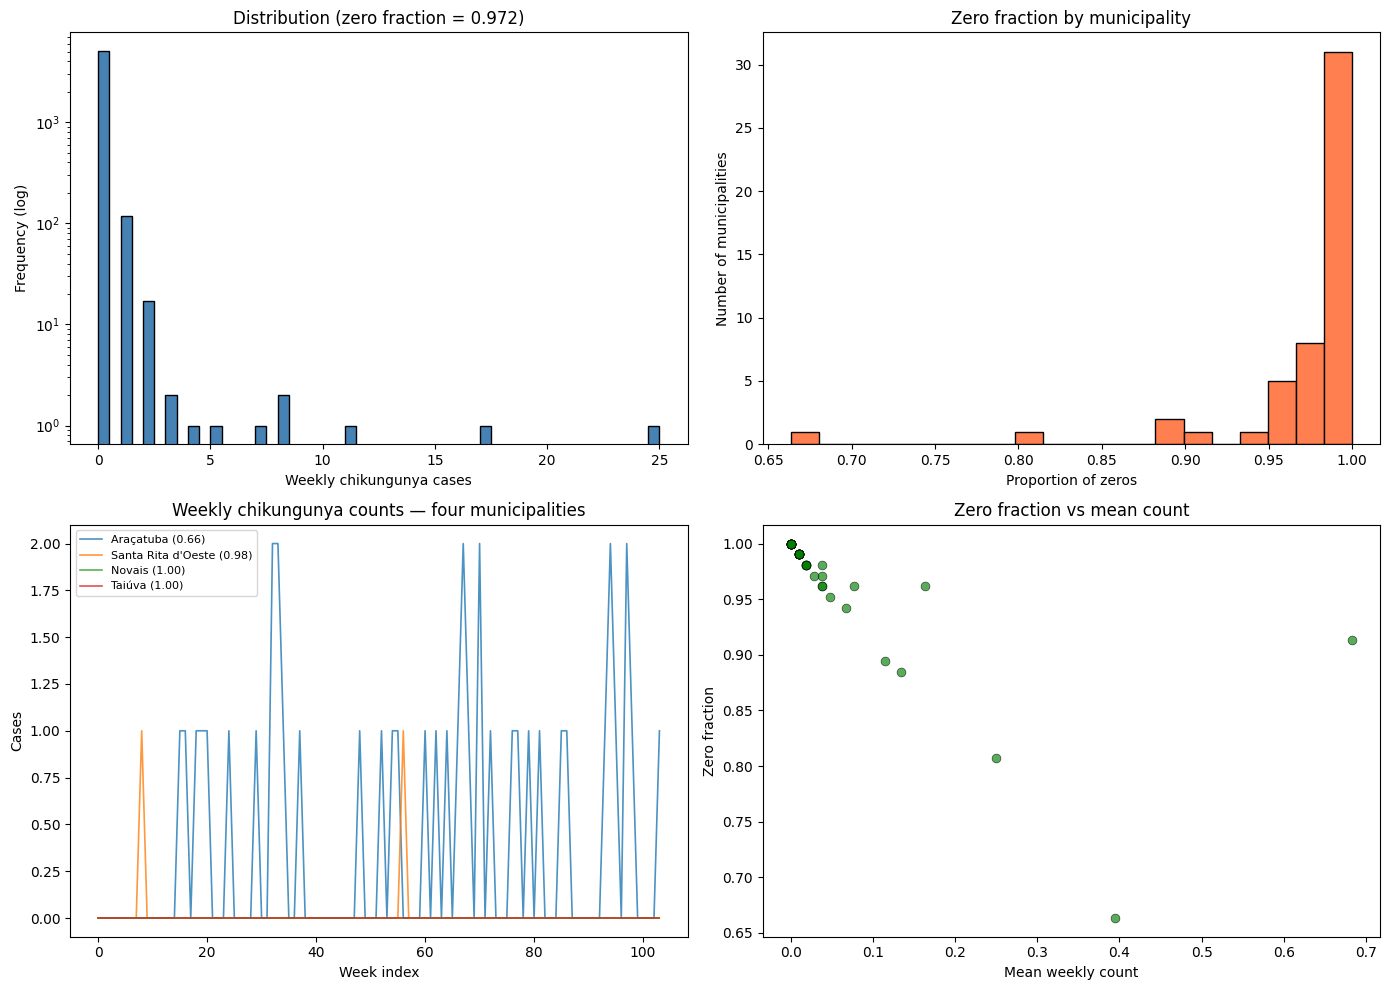

Exploratory plot saved.


In [ ]:
# CELL 5: EXPLORATORY PLOTS FOR CHIKUNGUNYA
import matplotlib.pyplot as plt

mun_stats = pd.DataFrame({
    'unit_id': panel.index,
    'zero_frac': (Y == 0).mean(axis=1),
    'mean_count': Y.mean(axis=1),
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(Y.flatten(), bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Weekly chikungunya cases')
axes[0, 0].set_ylabel('Frequency (log)')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title(f'Distribution (zero fraction = {(Y==0).mean():.3f})')

axes[0, 1].hist(mun_stats['zero_frac'], bins=20, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Proportion of zeros')
axes[0, 1].set_ylabel('Number of municipalities')
axes[0, 1].set_title('Zero fraction by municipality')

# Time series for 4 municipalities
sorted_idx = np.argsort(mun_stats['zero_frac'].values)
name_map = dict(zip(selected['geocode'], selected['name']))
unit_names = [name_map.get(uid, f'Unit {uid}') for uid in panel.index]
chosen = [sorted_idx[0], sorted_idx[len(sorted_idx)//3],
          sorted_idx[2*len(sorted_idx)//3], sorted_idx[-1]]
for i in chosen:
    axes[1, 0].plot(Y[i], alpha=0.8, linewidth=1.2,
                    label=f"{unit_names[i]} ({mun_stats['zero_frac'].iloc[i]:.2f})")
axes[1, 0].set_xlabel('Week index')
axes[1, 0].set_ylabel('Cases')
axes[1, 0].legend(fontsize=8)
axes[1, 0].set_title('Weekly chikungunya counts — four municipalities')

axes[1, 1].scatter(mun_stats['mean_count'], mun_stats['zero_frac'],
                  alpha=0.65, s=40, color='green', edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Mean weekly count')
axes[1, 1].set_ylabel('Zero fraction')
axes[1, 1].set_title('Zero fraction vs mean count')

plt.tight_layout()
plt.savefig('/content/chikungunya_exploratory.png', dpi=150)
plt.show()
print("Exploratory plot saved.")

In [ ]:
# CELL 6: WRITE FOUR STAN MODELS
# Reuse the same four models as the dengue comparison:
# HZMPS, ZIP, ZINB, HNB.

# --- HZMPS ---
hzmps_stan = r"""
functions {
  real partial_sum_hzmps(array[] int y_slice, int start, int end,
                         array[] int unit, array[] int time,
                         vector omega, matrix mu) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      if (y_slice[k] == 0) lp += log1m(omega[i]);
      else lp += log(omega[i]) - mu[i,t] + y_slice[k]*log(mu[i,t])
                 - lgamma(y_slice[k]+1) - log1m_exp(-mu[i,t]);
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] omega;
  for (i in 1:N) omega[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 10);
  gamma_raw ~ normal(-1, 1);
  sigma_eta ~ normal(0, 3);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 5);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 1);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_hzmps, y, grainsize, unit, time, omega, mu);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    if (y[m] == 0) log_lik[m] = log1m(omega[i]);
    else log_lik[m] = log(omega[i]) - mu[i,t] + y[m]*log(mu[i,t])
                    - lgamma(y[m]+1) - log1m_exp(-mu[i,t]);
  }
}
"""

with open('/content/ck_hzmps.stan', 'w') as f:
    f.write(hzmps_stan)

# --- Reuse ZIP, ZINB, HNB from the dengue comparison ---
# They are the same files we already wrote. Copy them from the previous session
# if still in memory, or re-write them. For brevity we assume the previous
# Stan files are on disk at /content/zip_ss.stan etc. If not, re-run Cell 3-5
# from the baseline comparison notebook.

print("Models ready. If zip_ss.stan / zinb_ss.stan / hnb_ss.stan are not on disk, ")
print("re-run Cells 3-5 from the baseline comparison notebook first.")

Models ready. If zip_ss.stan / zinb_ss.stan / hnb_ss.stan are not on disk, 
re-run Cells 3-5 from the baseline comparison notebook first.


In [ ]:
# CELL 6b: WRITE BASELINE STAN MODELS (ZIP, ZINB, HNB)
# These are the same three baseline models used in the dengue
# comparison. Re-created here because the previous session's
# files are not accessible in this fresh Colab.

# --- ZIP ---
zip_code = r"""
functions {
  real partial_sum_zip(array[] int y_slice, int start, int end,
                       array[] int unit, array[] int time,
                       vector pi_i, matrix mu) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      if (y_slice[k] == 0)
        lp += log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) - mu[i, t]);
      else
        lp += log1m(pi_i[i]) + y_slice[k]*log(mu[i,t]) - mu[i,t]
              - lgamma(y_slice[k]+1);
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] pi_i;
  for (i in 1:N) pi_i[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 3);
  gamma_raw ~ normal(-1, 1);
  sigma_eta ~ normal(0, 1);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 5);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 1);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_zip, y, grainsize, unit, time, pi_i, mu);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    if (y[m] == 0) log_lik[m] = log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) - mu[i,t]);
    else log_lik[m] = log1m(pi_i[i]) + y[m]*log(mu[i,t]) - mu[i,t] - lgamma(y[m]+1);
  }
}
"""

# --- ZINB ---
zinb_code = r"""
functions {
  real partial_sum_zinb(array[] int y_slice, int start, int end,
                        array[] int unit, array[] int time,
                        vector pi_i, matrix mu, real phi) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      real mu_it = mu[i, t];
      real nb0 = phi * log(phi / (phi + mu_it));
      if (y_slice[k] == 0) {
        lp += log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) + nb0);
      } else {
        real log_nb = lgamma(y_slice[k] + phi) - lgamma(phi)
                      - lgamma(y_slice[k] + 1)
                      + phi * log(phi / (phi + mu_it))
                      + y_slice[k] * log(mu_it / (phi + mu_it));
        lp += log1m(pi_i[i]) + log_nb;
      }
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
  real<lower=0> phi;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] pi_i;
  for (i in 1:N) pi_i[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 3);
  gamma_raw ~ normal(-1, 1);
  sigma_eta ~ normal(0, 1);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 5);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 1);
  phi ~ normal(0, 5);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_zinb, y, grainsize, unit, time, pi_i, mu, phi);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    real mu_it = mu[i, t];
    real log_nb = lgamma(y[m] + phi) - lgamma(phi) - lgamma(y[m] + 1)
                  + phi * log(phi / (phi + mu_it))
                  + y[m] * log(mu_it / (phi + mu_it));
    if (y[m] == 0)
      log_lik[m] = log_sum_exp(log(pi_i[i]),
                               log1m(pi_i[i]) + phi * log(phi / (phi + mu_it)));
    else
      log_lik[m] = log1m(pi_i[i]) + log_nb;
  }
}
"""

# --- HNB ---
hnb_code = r"""
functions {
  real partial_sum_hnb(array[] int y_slice, int start, int end,
                       array[] int unit, array[] int time,
                       vector omega, matrix mu, real phi) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      real mu_it = mu[i, t];
      real nb0 = phi * log(phi / (phi + mu_it));
      real log_norm = log1m_exp(nb0);
      if (y_slice[k] == 0) {
        lp += log1m(omega[i]);
      } else {
        real log_nb = lgamma(y_slice[k] + phi) - lgamma(phi)
                      - lgamma(y_slice[k] + 1)
                      + phi * log(phi / (phi + mu_it))
                      + y_slice[k] * log(mu_it / (phi + mu_it));
        lp += log(omega[i]) + log_nb - log_norm;
      }
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
  real<lower=0> phi;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] omega;
  for (i in 1:N) omega[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 3);
  gamma_raw ~ normal(-1, 1);
  sigma_eta ~ normal(0, 1);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 5);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 1);
  phi ~ normal(0, 5);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_hnb, y, grainsize, unit, time, omega, mu, phi);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    real mu_it = mu[i, t];
    real nb0 = phi * log(phi / (phi + mu_it));
    real log_norm = log1m_exp(nb0);
    real log_nb = lgamma(y[m] + phi) - lgamma(phi) - lgamma(y[m] + 1)
                  + phi * log(phi / (phi + mu_it))
                  + y[m] * log(mu_it / (phi + mu_it));
    if (y[m] == 0) log_lik[m] = log1m(omega[i]);
    else log_lik[m] = log(omega[i]) + log_nb - log_norm;
  }
}
"""

# --- Write all three to disk ---
with open('/content/zip_ss.stan', 'w') as f:
    f.write(zip_code)
with open('/content/zinb_ss.stan', 'w') as f:
    f.write(zinb_code)
with open('/content/hnb_ss.stan', 'w') as f:
    f.write(hnb_code)

print("Wrote all three baseline Stan files:")
print("  /content/zip_ss.stan")
print("  /content/zinb_ss.stan")
print("  /content/hnb_ss.stan")

Wrote all three baseline Stan files:
  /content/zip_ss.stan
  /content/zinb_ss.stan
  /content/hnb_ss.stan


In [ ]:
# CELL 7: COMPILE ALL FOUR MODELS
import cmdstanpy, time

models = {}
for name, path in [
    ('hzmps', '/content/ck_hzmps.stan'),
    ('zip',   '/content/zip_ss.stan'),
    ('zinb',  '/content/zinb_ss.stan'),
    ('hnb',   '/content/hnb_ss.stan'),
]:
    print(f"Compiling {name}...")
    t0 = time.time()
    models[name] = cmdstanpy.CmdStanModel(
        stan_file=path,
        cpp_options={'STAN_THREADS': 'true'},
        force_compile=True)
    print(f"  {name} compiled in {time.time()-t0:.1f} s")

Compiling hzmps...
  hzmps compiled in 28.5 s
Compiling zip...
  zip compiled in 30.1 s
Compiling zinb...
  zinb compiled in 28.8 s
Compiling hnb...
  hnb compiled in 29.1 s


In [ ]:
# CELL 8: FIT FOUR MODELS ON CHIKUNGUNYA DATA
# This is the long cell (~8-10 hours).  thi tab should be opened.

def fit_model(model, name, stan_data):
    print(f"\n{'='*60}\nFitting {name}...\n{'='*60}")
    t0 = time.time()
    fit = model.sample(
        data=stan_data,
        chains=2, parallel_chains=2, threads_per_chain=2,
        iter_warmup=1000, iter_sampling=1000,
        seed=42, adapt_delta=0.97, max_treedepth=12,
        show_progress=True, output_dir=f'/content/ck_fit_{name}',
    )
    print(f"{name} done in {(time.time()-t0)/60:.1f} min")
    fit.draws_pd().to_csv(f'/content/ck_{name}_draws.csv', index=False)
    fit.summary().to_csv(f'/content/ck_{name}_summary.csv')
    return fit

fit_hzmps = fit_model(models['hzmps'], 'hzmps', base_data)
fit_zip   = fit_model(models['zip'],   'zip',   base_data)
fit_zinb  = fit_model(models['zinb'],  'zinb',  base_data)
fit_hnb   = fit_model(models['hnb'],   'hnb',   base_data)

print("\nAll chikungunya fits complete.")


Fitting hzmps...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

                                                                                                                                                                
hzmps done in 16.1 min

Fitting zip...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

...

zinb done in 41.5 min

Fitting hnb...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

	Chain 1 had 5 divergent transitions (0.5%)
	Chain 2 had 1 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


hnb done in 22.5 min

All chikungunya fits complete.


In [ ]:
# CELL 9: WAIC COMPARISON
import pandas as pd, numpy as np

def waic_from_draws(csv_path):
    df = pd.read_csv(csv_path)
    cols = [c for c in df.columns if c.startswith('log_lik[')]
    idx = [int(c.replace('log_lik[', '').replace(']', '')) for c in cols]
    order = np.argsort(idx)
    ll = df[[cols[i] for i in order]].values
    max_ll = ll.max(axis=0, keepdims=True)
    lppd = float(np.sum(max_ll.squeeze() + np.log(np.exp(ll - max_ll).mean(axis=0))))
    p_waic = float(np.sum(ll.var(axis=0, ddof=1)))
    return -2 * (lppd - p_waic), lppd, p_waic

rows = []
for name, label in [
    ('hzmps', 'HZMPS-SS'),
    ('zip',   'ZIP-SS'),
    ('zinb',  'ZINB-SS'),
    ('hnb',   'HNB-SS'),
]:
    waic, lppd, p = waic_from_draws(f'/content/ck_{name}_draws.csv')
    rows.append({'Model': label, 'WAIC': waic, 'lppd': lppd, 'p_waic': p})

results = pd.DataFrame(rows).sort_values('WAIC').reset_index(drop=True)
results['ΔWAIC'] = results['WAIC'] - results['WAIC'].min()

print("=" * 72)
print("CHIKUNGUNYA MODEL COMPARISON")
print("=" * 72)
print(results.to_string(index=False))

results.to_csv('/content/ck_model_comparison.csv', index=False)
print("\nSaved: ck_model_comparison.csv")

CHIKUNGUNYA MODEL COMPARISON
   Model        WAIC        lppd     p_waic      ΔWAIC
  ZIP-SS 1152.114981 -440.059087 135.998404   0.000000
 ZINB-SS 1161.257208 -449.009930 131.618674   9.142227
HZMPS-SS 1246.299216 -570.865674  52.283934  94.184236
  HNB-SS 1254.679638 -578.148942  49.190877 102.564657

Saved: ck_model_comparison.csv


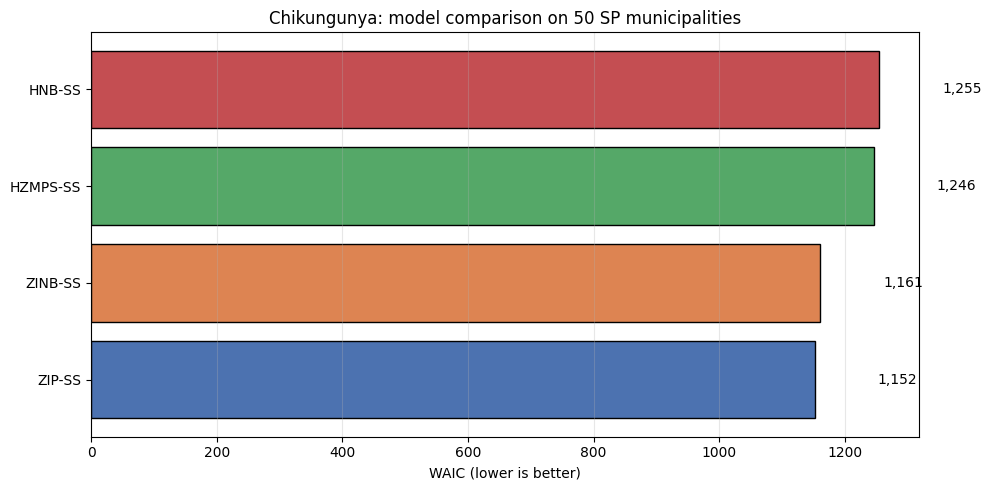

Figure saved.

SIDE-BY-SIDE: DENGUE vs CHIKUNGUNYA
    Disease    Model       ΔWAIC
     Dengue   ZIP-SS    0.000000
     Dengue  ZINB-SS  709.000000
     Dengue HZMPS-v5 2083.000000
     Dengue   HNB-SS 2744.000000
Chikungunya   ZIP-SS    0.000000
Chikungunya  ZINB-SS    9.142227
Chikungunya HZMPS-SS   94.184236
Chikungunya   HNB-SS  102.564657


In [16]:
# CELL 10: COMPARISON FIGURE
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#55A868' if 'HZMPS' in m else
          '#4C72B0' if 'ZIP' in m else
          '#DD8452' if 'ZINB' in m else '#C44E52'
          for m in results['Model']]
bars = ax.barh(results['Model'], results['WAIC'],
               color=colors, edgecolor='black')
for bar, w in zip(bars, results['WAIC']):
    ax.text(w + 100, bar.get_y() + bar.get_height()/2,
            f'{w:,.0f}', va='center', fontsize=10)
ax.set_xlabel('WAIC (lower is better)')
ax.set_title('Chikungunya: model comparison on 50 SP municipalities')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/ck_model_comparison.png', dpi=150)
plt.show()
print("Figure saved.")

# --- Combined table with dengue for the paper ---
print("\n" + "=" * 72)
print("SIDE-BY-SIDE: DENGUE vs CHIKUNGUNYA")
print("=" * 72)
dengue_results = pd.DataFrame([
    {'Disease': 'Dengue',      'Model': 'ZIP-SS',   'ΔWAIC': 0},
    {'Disease': 'Dengue',      'Model': 'ZINB-SS',  'ΔWAIC': 709},
    {'Disease': 'Dengue',      'Model': 'HZMPS-v5', 'ΔWAIC': 2083},
    {'Disease': 'Dengue',      'Model': 'HNB-SS',   'ΔWAIC': 2744},
])
ck_results = results[['Model', 'ΔWAIC']].copy()
ck_results.insert(0, 'Disease', 'Chikungunya')
combined = pd.concat([dengue_results, ck_results], ignore_index=True)
print(combined.to_string(index=False))
combined.to_csv('/content/side_by_side_comparison.csv', index=False)